In [1]:
import os, time
import pandas as pd, numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from timeit import default_timer as timer

In [2]:
# 1) Data Prep: 8 sample fashion items (5-10 items requested)
products = [
    {"id": 1, "name": "Boho Dress", "desc": "Flowy maxi dress with earthy tones and fringe details, perfect for festivals and free-spirited days.", "tags": ["boho","festival","earthy"]},
    {"id": 2, "name": "Urban Bomber Jacket", "desc": "Sleek bomber with reflective accents and a tailored fit for energetic city nights.", "tags": ["urban","chic","energetic"]},
    {"id": 3, "name": "Cozy Knit Sweater", "desc": "Chunky knit, oversized silhouette for comfy coffee-shop vibes and chilly weekends.", "tags": ["cozy","casual","warm"]},
    {"id": 4, "name": "Minimalist Slip Dress", "desc": "Clean lines and neutral tones — versatile for day-to-night city looks.", "tags": ["minimalist","chic","urban"]},
    {"id": 5, "name": "Rugged Denim Jacket", "desc": "Distressed denim with vintage wash — rugged, versatile, and effortlessly cool.", "tags": ["casual","vintage","rugged"]},
    {"id": 6, "name": "Sporty Mesh Sneakers", "desc": "Lightweight sneakers with breathable mesh and bold soles for active streetwear.", "tags": ["sporty","energetic","streetwear"]},
    {"id": 7, "name": "Silk Scarf", "desc": "Luxurious silk scarf with vibrant patterns — adds instant elegance to any outfit.", "tags": ["elegant","vibrant","accessory"]},
    {"id": 8, "name": "Plaid Wool Coat", "desc": "Structured wool coat in plaid; smart-casual and great for colder city commutes.", "tags": ["warm","smart","classy"]}
]

df = pd.DataFrame(products)
df["text_for_embed"] = df["name"] + ". " + df["desc"] + " " + df["tags"].apply(lambda t: " ".join(t))
df = df.set_index("id")
df[["name","desc","tags","text_for_embed"]]


,name,desc,tags,text_for_embed
id,,,,
1,Boho Dress,Flowy maxi dress with earthy tones and fringe ...,"[boho, festival, earthy]",Boho Dress. Flowy maxi dress with earthy tones...
2,Urban Bomber Jacket,Sleek bomber with reflective accents and a tai...,"[urban, chic, energetic]",Urban Bomber Jacket. Sleek bomber with reflect...
3,Cozy Knit Sweater,"Chunky knit, oversized silhouette for comfy co...","[cozy, casual, warm]","Cozy Knit Sweater. Chunky knit, oversized silh..."
4,Minimalist Slip Dress,Clean lines and neutral tones — versatile for ...,"[minimalist, chic, urban]",Minimalist Slip Dress. Clean lines and neutral...
5,Rugged Denim Jacket,"Distressed denim with vintage wash — rugged, v...","[casual, vintage, rugged]",Rugged Denim Jacket. Distressed denim with vin...
6,Sporty Mesh Sneakers,Lightweight sneakers with breathable mesh and ...,"[sporty, energetic, streetwear]",Sporty Mesh Sneakers. Lightweight sneakers wit...
7,Silk Scarf,Luxurious silk scarf with vibrant patterns — a...,"[elegant, vibrant, accessory]",Silk Scarf. Luxurious silk scarf with vibrant ...
8,Plaid Wool Coat,Structured wool coat in plaid; smart-casual an...,"[warm, smart, classy]",Plaid Wool Coat. Structured wool coat in plaid...


In [3]:
import os, math

try:
    import openai
    openai.api_key = os.getenv("OPENAI_API_KEY")
    def get_embedding_openai(text, model="text-embedding-ada-002"):
        
        resp = openai.Embedding.create(input=text, model=model)
        return np.array(resp["data"][0]["embedding"], dtype=np.float32)
    client_type = "openai"
except Exception:
    
    try:
        from openai import OpenAI
        client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
        def get_embedding_openai(text, model="text-embedding-ada-002"):
            resp = client.embeddings.create(model=model, input=text)
            return np.array(resp.data[0].embedding, dtype=np.float32)
        client_type = "OpenAI"
    except Exception:
        client_type = None

print("OpenAI client available?", client_type)
if client_type:
    
    product_embeddings = {}
    for idx, row in df.iterrows():
        product_embeddings[idx] = get_embedding_openai(row["text_for_embed"])
    
    X = np.vstack([product_embeddings[idx] for idx in df.index])
    print("Created OpenAI embeddings shape:", X.shape)
else:
    print("OpenAI client not found. Skip to TF-IDF fallback.")


OpenAI client available? None
OpenAI client not found. Skip to TF-IDF fallback.


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=1024)
X_tfidf = vectorizer.fit_transform(df["text_for_embed"]).toarray()
X_tfidf.shape


(8, 225)

In [5]:
from sklearn.preprocessing import normalize

def build_index(emb_matrix):
    
    return normalize(emb_matrix, axis=1)


if 'X' in globals():
    EMB = build_index(X)           
    emb_source = "openai"
else:
    EMB = build_index(X_tfidf)     
    emb_source = "tfidf"

id_list = list(df.index)
print("Using embeddings:", emb_source, "count:", EMB.shape[0])

def match_query(query_text, top_k=3):
    
    if emb_source == "openai":
        q_vec = get_embedding_openai(query_text)
        q_vec = q_vec.reshape(1,-1)
    else:
        q_vec = vectorizer.transform([query_text]).toarray()
    q_vec = normalize(q_vec, axis=1)
    sims = (EMB @ q_vec.T).flatten()  
    
    idx_sorted = np.argsort(sims)[::-1][:top_k]
    results = []
    for i in idx_sorted:
        pid = id_list[i]
        results.append({
            "id": pid,
            "name": df.loc[pid,"name"],
            "desc": df.loc[pid,"desc"],
            "tags": df.loc[pid,"tags"],
            "score": float(sims[i])
        })
    return results, float(sims[idx_sorted[0]])


Using embeddings: tfidf count: 8


In [6]:

FALLBACK_THRESHOLD = 0.35  

def run_query_with_fallback(q, top_k=3):
    results, best = match_query(q, top_k)
    fallback = None
    if best < FALLBACK_THRESHOLD:
        fallback = {
            "message": f"No strong match found (best score {best:.3f}). Try broader vibes or choose from popular tags.",
            "suggest_tags": sorted(set(sum(df.tags.tolist(), [])))  # unique tags
        }
    return results, best, fallback

q = "energetic urban chic"
res, best, fb = run_query_with_fallback(q)
print("Query:", q)
for r in res:
    print(f"- {r['name']} (score: {r['score']:.3f})")
print("Fallback:", fb)


Query: energetic urban chic
- Urban Bomber Jacket (score: 0.431)
- Minimalist Slip Dress (score: 0.138)
- Sporty Mesh Sneakers (score: 0.064)
Fallback: None


In [7]:
queries = ["energetic urban chic", "cozy weekend knit", "earthy festival boho"]
records = []
for q in queries:
    start = timer()
    results, best, fallback = run_query_with_fallback(q, top_k=3)
    elapsed_ms = (timer() - start) * 1000
    good = best > 0.7    
    records.append({
        "query": q,
        "best_score": best,
        "good_match": good,
        "latency_ms": elapsed_ms,
        "top_1": results[0]["name"],
        "top_2": results[1]["name"],
        "top_3": results[2]["name"],
        "fallback": fallback
    })

eval_df = pd.DataFrame(records)
eval_df


,query,best_score,good_match,latency_ms,top_1,top_2,top_3,fallback
0,energetic urban chic,0.430749,False,3.7147,Urban Bomber Jacket,Minimalist Slip Dress,Sporty Mesh Sneakers,None
1,cozy weekend knit,0.467050,False,2.2034,Cozy Knit Sweater,Plaid Wool Coat,Silk Scarf,None
2,earthy festival boho,0.440874,False,1.9485,Boho Dress,Plaid Wool Coat,Silk Scarf,None


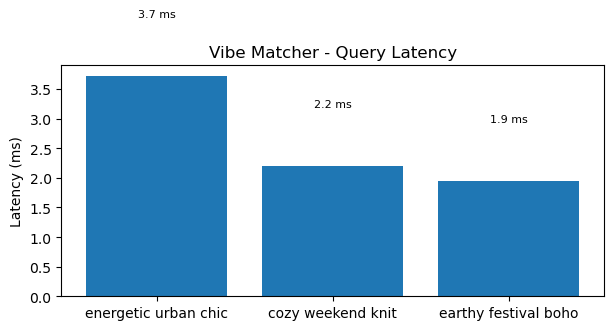

Mean latency: 2.6 ms  |  Good match rate (score>0.7): 0.0%


In [8]:
plt.figure(figsize=(7,3))
plt.bar(eval_df["query"], eval_df["latency_ms"])
plt.ylabel("Latency (ms)")
plt.title("Vibe Matcher - Query Latency")
for i,v in enumerate(eval_df["latency_ms"]):
    plt.text(i, v+1, f"{v:.1f} ms", ha='center', fontsize=8)
plt.show()

mean_latency = eval_df["latency_ms"].mean()
good_rate = eval_df["good_match"].mean()
print(f"Mean latency: {mean_latency:.1f} ms  |  Good match rate (score>0.7): {good_rate*100:.1f}%")
